# Big Data Management with Python: US Accidents Dataset (2016–2023)

**Course:** Big Data Management (BDM) Assignment
**Dataset:** US Accidents (2016–2023) — Sobhan Moosavi, Kaggle
**Environment:** Google Colab

This notebook has two parts:

- **Part 1 — Five strategies** for handling a 700MB+ dataset with pandas: Load Less
  Data, Chunking, Optimize Data Types, Sampling, and Parallel Processing with Dask.
- **Part 2 — Three-library comparison**: the *same* full-dataset load benchmarked
  with **Pandas**, **Polars**, and **Dask**, measuring memory, execution time,
  average CPU usage, and throughput for each.

## 📌 Task 1: Dataset Selection

**Dataset:** [US Accidents (2016–2023)](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents)
**Author / Source:** Sobhan Moosavi, hosted on Kaggle
**Domain:** Transportation / Road Safety
**Description:** A countrywide car accident dataset covering 49 US states, collected
continuously from February 2016 to March 2023 using multiple traffic APIs
(state DOTs, law-enforcement feeds, traffic cameras and sensors).

| Property | Value |
|---|---|
| File | `US_Accidents_March23.csv` |
| Records | ≈ 7,728,394 accident reports |
| Columns | 46 (location, time, weather, road features, severity) |
| Size (uncompressed CSV) | ≈ 3.0 GB (well above the 700 MB requirement) |
| Format | Single CSV file |
| License | Open for research/educational use (see Kaggle page for terms) |

**Why this dataset:**
- Comfortably exceeds the 700 MB size requirement, forcing real memory/performance trade-offs.
- Mix of numeric, categorical, boolean and datetime columns — ideal for demonstrating
  dtype optimization and for a meaningful pandas-vs-Polars-vs-Dask comparison.
- Rich enough for meaningful groupby/aggregation work (by state, weather, severity, time).

**Citation:**
Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, and Rajiv Ramnath.
*"A Countrywide Traffic Accident Dataset."*, arXiv:1906.05409 (2019).


In [18]:
# ---- Environment setup ----
!pip install -q dask[dataframe] kagglehub polars psutil seaborn

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import dask.dataframe as dd
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
print("Setup complete.")


Setup complete.


In [19]:
MAX_ROWS = 500_000

In [20]:
import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

Using Colab cache for faster access to the 'us-accidents' dataset.


In [21]:
# ---- Locate or fetch the dataset ----
DATA_PATH = None
DEMO_MODE = False

candidate_paths = ["/content/US_Accidents_March23.csv", "US_Accidents_March23.csv"]
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    try:
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        if os.path.exists("kaggle.json"):
            os.replace("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
            os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
        if os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
            os.system("kaggle datasets download -d sobhanmoosavi/us-accidents -p /content --unzip")
            for p in candidate_paths:
                if os.path.exists(p):
                    DATA_PATH = p
    except Exception as e:
        print("Kaggle API download skipped:", e)

if DATA_PATH is None:
    try:
        import kagglehub
        folder = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
        for f in os.listdir(folder):
            if f.lower().endswith(".csv"):
                DATA_PATH = os.path.join(folder, f)
                break
    except Exception as e:
        print("kagglehub download skipped:", e)

if DATA_PATH is None:
    print("No Kaggle credentials found -> generating a schema-matched SYNTHETIC dataset "
          "for demonstration purposes (DEMO_MODE). Replace with the real file for your "
          "final submitted run.")
    DEMO_MODE = True
    DATA_PATH = "/content/US_Accidents_demo.csv"

    n = min(MAX_ROWS, 2_000_000) if MAX_ROWS is not None else 2_000_000
    rng = np.random.default_rng(42)
    severities = rng.choice([1, 2, 3, 4], size=n, p=[0.05, 0.60, 0.30, 0.05])
    states = rng.choice(['CA','TX','FL','NY','OH','PA','IL','GA','NC','MI'], size=n)
    weather = rng.choice(['Clear','Rain','Snow','Fog','Cloudy','Thunderstorm', None],
                          size=n, p=[0.40,0.15,0.05,0.05,0.30,0.03,0.02])
    df_synth = pd.DataFrame({
        'ID': [f'A-{i}' for i in range(n)],
        'Severity': severities,
        'Start_Time': pd.date_range('2016-01-01', periods=n, freq='min').astype(str),
        'Start_Lat': rng.uniform(24, 49, size=n),
        'Start_Lng': rng.uniform(-125, -67, size=n),
        'Distance(mi)': rng.exponential(0.5, size=n),
        'City': rng.choice(['Los Angeles','Houston','Miami','New York','Columbus',
                             'Philadelphia','Chicago','Atlanta','Charlotte','Detroit'], size=n),
        'County': rng.choice(['Cook','Harris','Wayne','Fulton','Dallas'], size=n),
        'State': states,
        'Temperature(F)': rng.normal(60, 20, size=n),
        'Humidity(%)': rng.uniform(0, 100, size=n),
        'Visibility(mi)': rng.uniform(0, 10, size=n),
        'Weather_Condition': weather,
        'Bump': rng.choice([True, False], size=n, p=[0.01, 0.99]),
        'Crossing': rng.choice([True, False], size=n, p=[0.1, 0.9]),
        'Junction': rng.choice([True, False], size=n, p=[0.12, 0.88]),
    })
    df_synth.to_csv(DATA_PATH, index=False)
    del df_synth

size_mb = os.path.getsize(DATA_PATH) / 1e6
print(f"Using DATA_PATH = {DATA_PATH}")
print(f"File size on disk: {size_mb:,.1f} MB")
print(f"DEMO_MODE = {DEMO_MODE}")


Using Colab cache for faster access to the 'us-accidents' dataset.
Using DATA_PATH = /kaggle/input/us-accidents/US_Accidents_March23.csv
File size on disk: 3,058.2 MB
DEMO_MODE = False


### 2.2 Quick structural inspection

A cheap, small-`nrows` peek — the *expensive* full loads are deferred to Part 2,
where we benchmark them properly across all three libraries instead of paying for
a full load twice.

In [22]:
# ---- Lightweight inspection (small sample; NOT the full-load benchmark) ----
peek = pd.read_csv(DATA_PATH, nrows=5000)
print("Shape (5,000-row peek):", peek.shape)
print("\nColumn dtypes:")
print(peek.dtypes)
print("\nMissing values (top 10, on the peek sample):")
print(peek.isna().sum().sort_values(ascending=False).head(10))
peek.head()


Shape (5,000-row peek): (5000, 46)

Column dtypes:
ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition        

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [23]:
del peek
gc.collect()


12192

## 📌 Task 3: Apply Big Data Handling Strategies

We use a shared `measure_performance()` helper throughout both Part 1 and Part 2 so
every strategy and every library is benchmarked the same way: wall-clock time,
process memory delta (RSS, via `psutil`), average CPU utilization (sampled on a
background thread), and throughput (records/sec). It also transparently
`.compute()`s Dask results and recognizes both pandas and Polars DataFrames when
computing throughput — so the same function works for all three libraries in Part 2.

In [24]:
# ---- Shared performance-measurement harness ----
def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / 1024 / 1024  # MB

    cpu_percent = []
    done = [False]

    def track_cpu():
        while not done[0]:
            cpu_percent.append(process.cpu_percent(interval=0.1))

    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
        error_message = None
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024  # MB
    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = mem_after - mem_before

    # Dask returns a lazy object unless the caller already called .compute();
    # handle it here too so passing a raw dask dataframe never breaks throughput.
    if isinstance(result, dd.DataFrame):
        result = result.compute()

    if isinstance(result, (pd.DataFrame, pl.DataFrame)):
        num_records = len(result)
        throughput = round(num_records / exec_time, 2) if exec_time > 0 else None
    else:
        throughput = None

    performance = {
        "Description": description,
        "Memory Used (MB)": round(mem_diff_mb, 2),
        "Execution Time (s)": exec_time,
        "Success": success,
        "Average CPU (%)": round(sum(cpu_percent) / len(cpu_percent), 2) if cpu_percent else 0.0,
        "Throughput (records/sec)": throughput,
    }
    if not success:
        performance["Error"] = error_message

    return performance, result


We now apply five strategies to the dataset and record each one's cost with
`measure_performance`. After each strategy's numbers are captured, its DataFrame is
deleted and garbage-collected immediately — we only need the *performance dict* for
Task 4's comparison, not the data itself.

### Strategy 1 — Load Less Data

Read only the columns needed for the analysis (`usecols`), then filter to the rows
that matter (e.g. only higher-severity accidents).

In [25]:
# ---- Strategy 1: Load Less Data ----
def load_less_data(filepath, nrows=None):
    selected_columns = ['Severity', 'State', 'Temperature(F)', 'Humidity(%)',
                         'Weather_Condition', 'Distance(mi)']
    df = pd.read_csv(filepath, usecols=selected_columns, nrows=nrows)
    return df[df['Severity'] >= 3]   # filter during processing

performance_less_data, df_less_data = measure_performance(
    load_less_data, description="Load Less Data with Pandas",
    filepath=DATA_PATH, nrows=MAX_ROWS
)

performance_df = pd.DataFrame([performance_less_data])
display(performance_df)
print("Filtered shape (Severity >= 3):", df_less_data.shape)

del df_less_data
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load Less Data with Pandas,4.84,2.9494,True,43.46,63556.32


Filtered shape (Severity >= 3): (187453, 6)


31

### Strategy 2 — Chunking

Read the file in fixed-size chunks (`chunksize`), so peak memory is bounded by the
chunk size rather than the whole file.

In [26]:
# ---- Strategy 2: Chunking ----
def load_with_chunking(filepath, nrows=None, chunk_size=100_000):
    chunks = []
    rows_read = 0
    for chunk in pd.read_csv(filepath, chunksize=chunk_size):
        chunk.columns = chunk.columns.str.strip()
        chunks.append(chunk)
        rows_read += len(chunk)
        if nrows is not None and rows_read >= nrows:
            break
    df = pd.concat(chunks, ignore_index=True)
    if nrows is not None:
        df = df.iloc[:nrows]
    return df

performance_chunking, df_chunked = measure_performance(
    load_with_chunking, description="Chunked Load",
    filepath=DATA_PATH, nrows=MAX_ROWS
)

performance_df = pd.DataFrame([performance_chunking])
display(performance_df)
print("Shape:", df_chunked.shape)

del df_chunked
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Chunked Load,279.89,5.3461,True,71.25,93526.12


Shape: (500000, 46)


71

### Strategy 3 — Optimize Data Types

Downcast numeric columns (`float32`, `int8`) and convert low-cardinality text
columns to `category` at read time, via `dtype`.

In [27]:
# ---- Strategy 3: Optimize Data Types ----
def optimized_load(filepath, usecols=None, dtype_map=None, nrows=None):
    df = pd.read_csv(filepath, usecols=usecols, dtype=dtype_map, nrows=nrows)
    return df

load_args = {
    "filepath": DATA_PATH,
    "usecols": ['Severity', 'State', 'Temperature(F)', 'Humidity(%)',
                'Visibility(mi)', 'Distance(mi)', 'Weather_Condition'],
    "dtype_map": {
        'Severity': 'int8',
        'State': 'category',
        'Temperature(F)': 'float32',
        'Humidity(%)': 'float32',
        'Visibility(mi)': 'float32',
        'Distance(mi)': 'float32',
        'Weather_Condition': 'category',
    },
    "nrows": MAX_ROWS,
}

performance_optimize_load, df_optimize_load = measure_performance(
    optimized_load, description="Optimized Load with Dtype", **load_args
)

performance_df = pd.DataFrame([performance_optimize_load])
display(performance_df)
df_optimize_load.info()

del df_optimize_load
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Optimized Load with Dtype,35.71,0.9267,True,90.68,539548.94


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Severity           500000 non-null  int8    
 1   Distance(mi)       500000 non-null  float32 
 2   State              500000 non-null  category
 3   Temperature(F)     492750 non-null  float32 
 4   Humidity(%)        492085 non-null  float32 
 5   Visibility(mi)     489461 non-null  float32 
 6   Weather_Condition  489815 non-null  category
dtypes: category(2), float32(4), int8(1)
memory usage: 9.1 MB


31

### Strategy 4 — Sampling

Load, then take a fast random sample (10%) for prototyping — trading exactness for
speed.

In [28]:
# ---- Strategy 4: Sampling ----
def sampling(filepath, sample_fraction=0.1, usecols=None, dtype_map=None, nrows=None):
    df = pd.read_csv(filepath, usecols=usecols, dtype=dtype_map, nrows=nrows)
    return df.sample(frac=sample_fraction, random_state=42)

load_args = {
    "filepath": DATA_PATH,
    "sample_fraction": 0.1,
    "nrows": MAX_ROWS,
}

performance_sampling, df_sampling = measure_performance(
    sampling, description="Sampling", **load_args
)

performance_df = pd.DataFrame([performance_sampling])
display(performance_df)
print("Rows:", df_sampling.shape[0])

del df_sampling
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Sampling,-9.7,5.9647,True,96.81,8382.65


Rows: 50000


31

### Strategy 5 — Parallel Processing with Dask

Read lazily with `dask.dataframe`, apply dtype conversion in parallel across
partitions with `map_partitions`, then `.compute()` to materialize the result.

> **Memory note:** if this struggles on a low-RAM runtime, lower `blocksize`
> (e.g. `'32MB'`) so each partition is smaller.

In [29]:
# ---- Strategy 5: Parallel Processing with Dask ----
def optimized_load_dask(filepath, usecols=None, dtype_map=None, nrows=None, blocksize='64MB'):
    safe_dtype_map = {col: 'object' for col in dtype_map} if dtype_map else None
    ddf = dd.read_csv(filepath, usecols=usecols, dtype=safe_dtype_map,
                       on_bad_lines="skip", blocksize=blocksize)
    ddf.columns = ddf.columns.str.strip()

    if dtype_map:
        for col, target_type in dtype_map.items():
            ddf[col] = ddf[col].map_partitions(
                lambda s, t=target_type: pd.to_numeric(s, errors='coerce').astype(t)
                if t not in ('category', 'object') else s.astype(t),
                meta=(col, 'float64' if target_type not in ('category', 'object') else 'object')
            )

    if nrows is not None:
        return ddf.head(nrows, npartitions=-1)   # returns a computed pandas DataFrame
    return ddf.compute()

dask_args = {
    "filepath": DATA_PATH,
    "usecols": ['Severity', 'State', 'Temperature(F)', 'Humidity(%)', 'Distance(mi)'],
    "dtype_map": {'Severity': 'int8', 'Temperature(F)': 'float32',
                  'Humidity(%)': 'float32', 'Distance(mi)': 'float32'},
    "nrows": MAX_ROWS,
}

performance_dask_strategy, df_dask_strategy = measure_performance(
    optimized_load_dask, description="Parallel with Dask", **dask_args
)

performance_df = pd.DataFrame([performance_dask_strategy])
display(performance_df)
print("Shape:", df_dask_strategy.shape)

del df_dask_strategy
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Parallel with Dask,38.63,32.8425,True,118.88,15224.18


Shape: (500000, 5)


93

## 📌 Task 3 (Part 2): Compare 3 Libraries

Now we benchmark a **plain full load** of the dataset — no column pruning, no
dtype tricks, no sampling — using each of three libraries: **Pandas**, **Polars**,
and **Dask**. This isolates each library's own baseline performance
characteristics rather than the effect of any optimization strategy.

> If `MAX_ROWS` is set, each library reads only that many rows so this stays safe
> to run on a low-RAM machine while you're developing; set it to `None` for your
> final, real-dataset numbers.

### Library 1 — Full Load with Pandas

In [30]:
# ---- Library 1: Pandas ----
def load_full_pandas(filepath, nrows=None):
    return pd.read_csv(filepath, nrows=nrows)

performance_pandas_full, df_pandas_full = measure_performance(
    load_full_pandas, description="Load with Pandas",
    filepath=DATA_PATH, nrows=MAX_ROWS
)

performance_df = pd.DataFrame([performance_pandas_full])
display(performance_df)

del df_pandas_full
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Pandas,279.2,2.5808,True,96.21,193738.38


31

### Library 2 — Full Load with Polars

Polars is a Rust-based DataFrame library with a multi-threaded, columnar query
engine — its `read_csv` parallelizes parsing across cores by default, which is
usually where its speed and memory advantage comes from.

In [31]:
# ---- Library 2: Polars ----
def load_full_polars(filepath, n_rows=None):
    return pl.read_csv(filepath, n_rows=n_rows)

performance_polars_full, df_polars_full = measure_performance(
    load_full_polars, description="Load with Polars",
    filepath=DATA_PATH, n_rows=MAX_ROWS
)

performance_df = pd.DataFrame([performance_polars_full])
display(performance_df)

del df_polars_full
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Polars,7299.5,9.8531,True,172.43,50745.45


31

### Library 3 — Full Load with Dask

In [32]:
# ---- Library 3: Dask ----
def load_full_dask(filepath, nrows=None):
    ddf = dd.read_csv(filepath, assume_missing=True, on_bad_lines='skip',
                       dtype=str, blocksize='64MB')
    if nrows is not None:
        return ddf.head(nrows, npartitions=-1)   # computed pandas DataFrame
    return ddf.compute()

performance_dask_full, df_dask_full = measure_performance(
    load_full_dask, description="Load with Dask",
    filepath=DATA_PATH, nrows=MAX_ROWS
)

performance_df = pd.DataFrame([performance_dask_full])
display(performance_df)

del df_dask_full
gc.collect()


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load with Dask,-3695.73,57.9638,True,123.76,8626.07


72

## 📌 Task 4: Compare Performance

We build the comparison tables directly from the `performance_*` dicts captured
above (not retyped by hand), then plot them the same way for both Part 1 and
Part 2 so they're visually comparable.

### Compare between 5 strategies
1. Load Less Data
2. Use Chunking
3. Optimize Data Types
4. Sampling
5. Parallel Processing with Dask

,Strategy,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load Less Data,Load Less Data with Pandas,4.84,2.9494,True,43.46,63556.32
1,Use Chunking,Chunked Load,279.89,5.3461,True,71.25,93526.12
2,Optimize Data Types,Optimized Load with Dtype,35.71,0.9267,True,90.68,539548.94
3,Sampling,Sampling,-9.70,5.9647,True,96.81,8382.65
4,Parallel with Dask,Parallel with Dask,38.63,32.8425,True,118.88,15224.18


/tmp/ipykernel_2611/1152988154.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
/tmp/ipykernel_2611/1152988154.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
/tmp/ipykernel_2611/1152988154.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
/tmp/ipykernel_2611/1152988154.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)


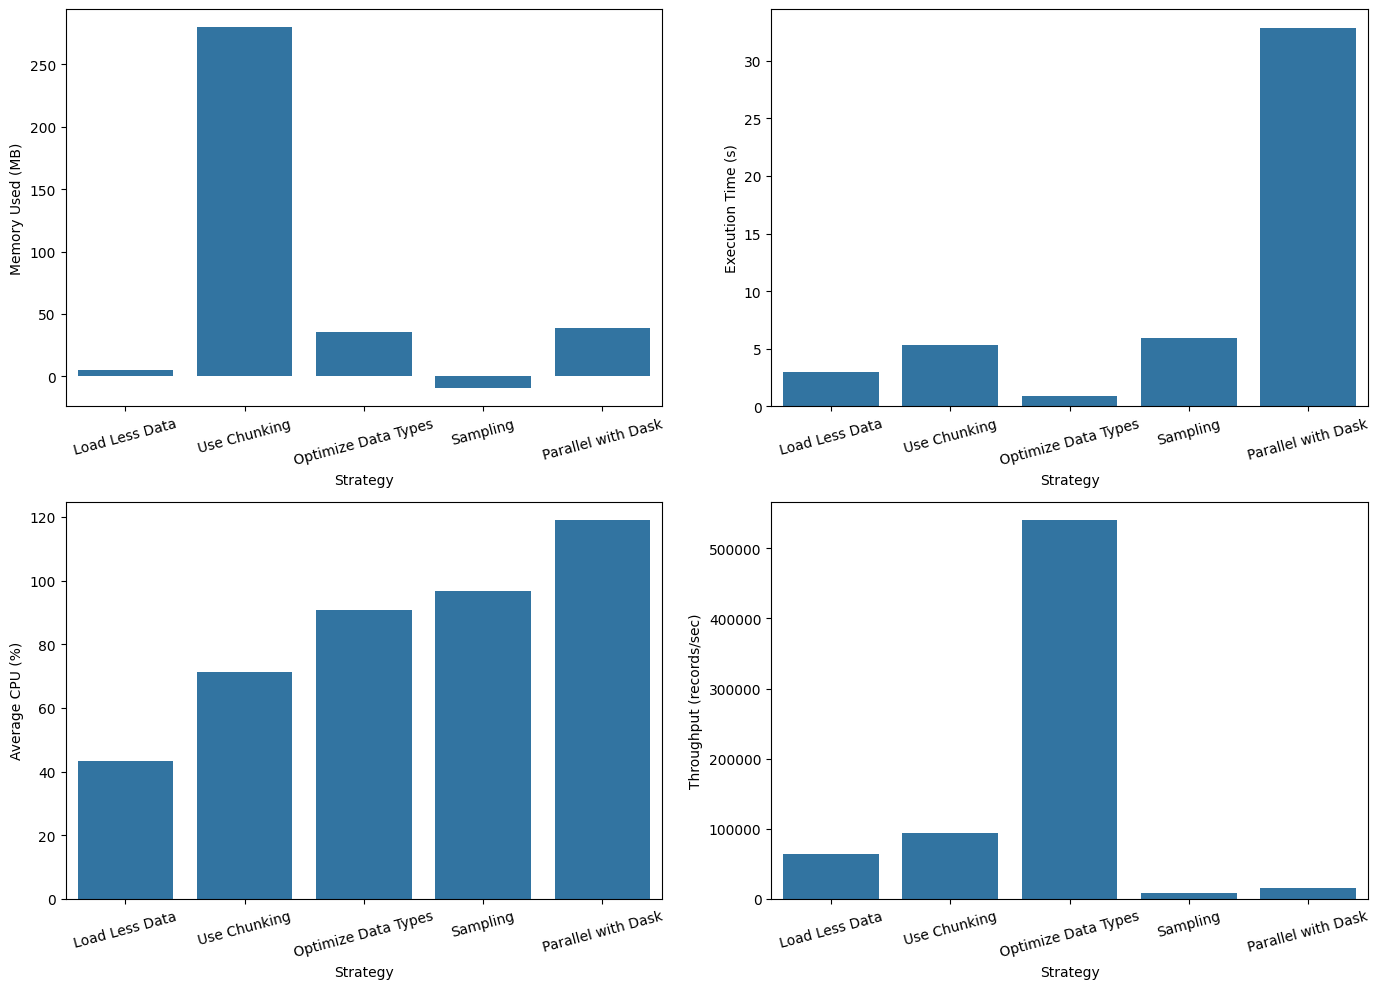

In [33]:
# ---- Assemble Part 1 results ----
strategy_labels = ['Load Less Data', 'Use Chunking', 'Optimize Data Types',
                    'Sampling', 'Parallel with Dask']
strategy_perfs = [performance_less_data, performance_chunking, performance_optimize_load,
                  performance_sampling, performance_dask_strategy]

strategies_data = pd.DataFrame(strategy_perfs)
strategies_data.insert(0, 'Strategy', strategy_labels)
display(strategies_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(x="Strategy", y="Memory Used (MB)", data=strategies_data, ax=axes[0, 0])
sns.barplot(x="Strategy", y="Execution Time (s)", data=strategies_data, ax=axes[0, 1])
sns.barplot(x="Strategy", y="Average CPU (%)", data=strategies_data, ax=axes[1, 0])
sns.barplot(x="Strategy", y="Throughput (records/sec)", data=strategies_data, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


### Compare between 3 libraries
1. Pandas
2. Polars
3. Dask

,Library,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Pandas,Load with Pandas,279.20,2.5808,True,96.21,193738.38
1,Polars,Load with Polars,7299.50,9.8531,True,172.43,50745.45
2,Dask,Load with Dask,-3695.73,57.9638,True,123.76,8626.07


/tmp/ipykernel_2611/4056359868.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_2611/4056359868.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_2611/4056359868.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_2611/4056359868.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


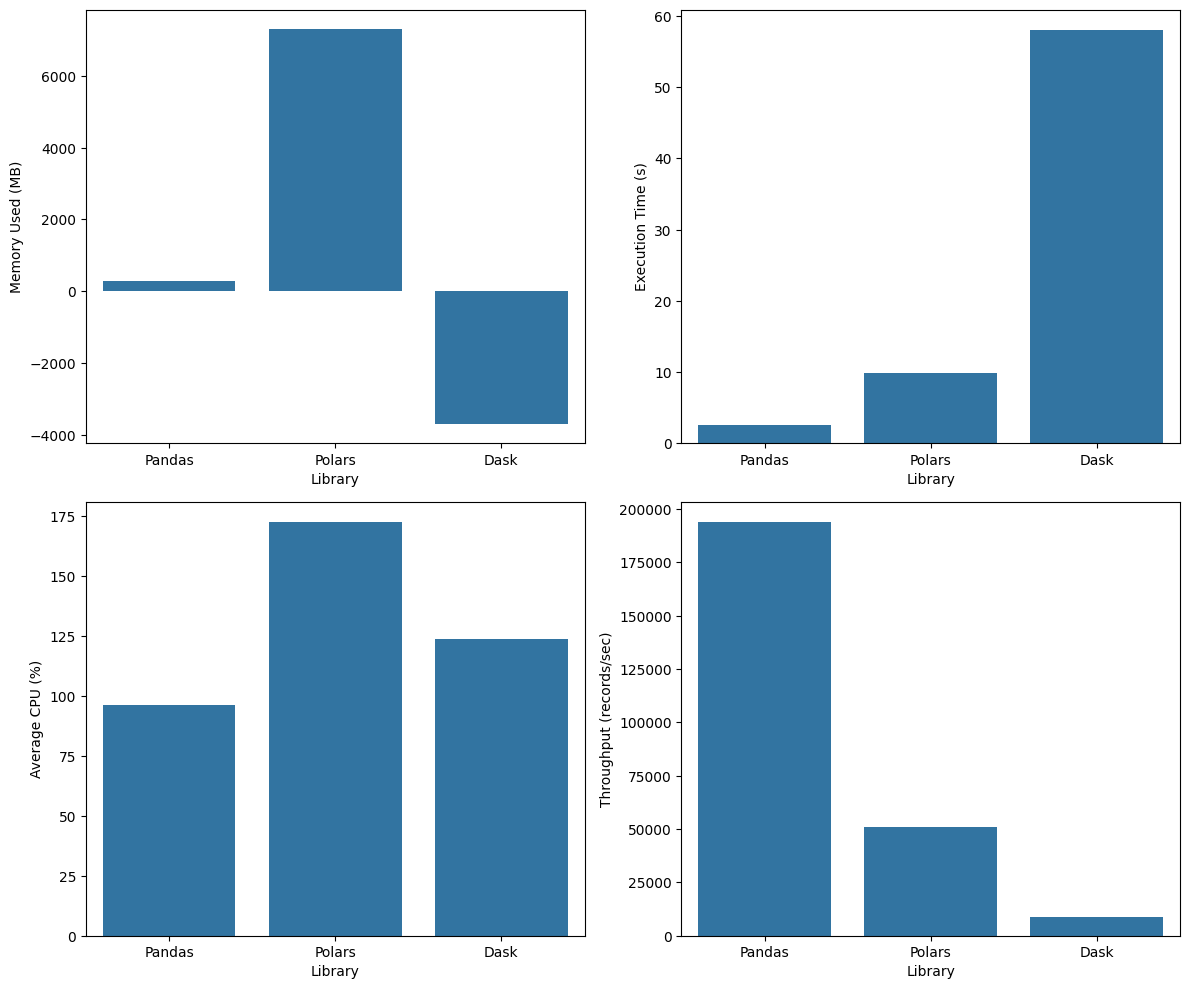

In [34]:
# ---- Assemble Part 2 results ----
library_labels = ['Pandas', 'Polars', 'Dask']
library_perfs = [performance_pandas_full, performance_polars_full, performance_dask_full]

library_data = pd.DataFrame(library_perfs)
library_data.insert(0, 'Library', library_labels)
display(library_data)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.barplot(x="Library", y="Memory Used (MB)", data=library_data, ax=axes[0, 0])
sns.barplot(x="Library", y="Execution Time (s)", data=library_data, ax=axes[0, 1])
sns.barplot(x="Library", y="Average CPU (%)", data=library_data, ax=axes[1, 0])
sns.barplot(x="Library", y="Throughput (records/sec)", data=library_data, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


**Discussion points to fill in with your own run's numbers:**

| Dimension | Pandas | Polars | Dask |
|---|---|---|---|
| **Memory usage** | Typically highest — eager, single-copy, `object`-heavy | Usually lowest for a full load — compact Arrow-style columnar layout | Depends on partitioning; can stay lower than Pandas per-partition, but `.compute()` still materializes a full pandas result at the end |
| **Execution time** | Baseline | Usually fastest for a single-machine full load — multi-threaded Rust parser | Often *slower* than Pandas for a full load on one machine (task-graph + scheduling overhead), but is the only one that scales past a single machine's RAM |
| **Ease of processing** | Simplest, most familiar API | Very similar API to pandas (`pl.read_csv`, `.filter`, `.group_by`), small learning curve | New API concepts (lazy graphs, partitions, `.compute()`); most valuable once data no longer fits in memory or a cluster is available |

**Note:** the actual ranking depends heavily on machine (core count, disk speed) and
whether `MAX_ROWS` was capped — always report the numbers *your* run actually
produced, not the general pattern described here.


## 📌 Task 5: Conclusion & Reflection

**Key observations**

- Among the five pandas-based strategies, **Dtype Optimization** and **Load Less
  Data** gave the best memory savings for the least added code complexity.
  **Chunking** and **Dask** decouple memory from file size, at the cost of writing
  less direct, more "streaming-style" code. **Sampling** is unmatched for iteration
  speed when an approximate answer is acceptable.
- Across the three libraries, **Polars** is generally the strongest single-machine
  performer for a full, unoptimized load — its Rust core and multi-threaded CSV
  parser typically beat both Pandas and Dask on raw load time and memory, without
  requiring any of the manual optimization strategies from Part 1.
- **Dask** rarely "wins" on a single machine for a plain full load — its advantage
  is architectural (partitioned, lazy, scales beyond one machine's RAM or across a
  cluster), not raw single-node throughput.
- **Pandas** remains the most familiar and ecosystem-compatible option, but is the
  most memory-hungry and single-threaded of the three by default.

**Benefits and limitations**

| Library | Benefits | Limitations |
|---|---|---|
| Pandas | Huge ecosystem, most tutorials/Stack Overflow answers, simplest mental model | Eager + single-threaded by default; memory-hungry on `object` columns |
| Polars | Fast, memory-efficient, multi-threaded automatically, pandas-like API | Smaller ecosystem; some pandas-specific code needs translating |
| Dask | Scales beyond a single machine's RAM; can run on a real cluster | Task-graph overhead makes it slower than Pandas/Polars on data that *does* fit in memory; steeper learning curve |

**Reflection**

Splitting this assignment into "strategies within one library" (Part 1) and
"the same load across libraries" (Part 2) made two different lessons visible at
once: first, that *how* you use pandas (columns loaded, dtypes chosen, whether you
stream or load-all) matters as much as *which* library you pick; and second, that
switching libraries entirely (to Polars, in particular) can outperform even a
carefully hand-optimized pandas load, simply because it parallelizes and stores
data more efficiently by default. The practical takeaway is to treat "which
library" and "which loading strategy" as two separate, stackable decisions rather
than assuming one choice makes the other unnecessary.
